In [1]:
from ovo import db, schedulers, storage, descriptors, descriptors_refolding, descriptors_rfdiffusion, design_logic, descriptor_logic, project_logic
from ovo import models_rfdiffusion, Threshold
import os
import time
import itertools

Registering plugin ovo_promb
Registering plugin ovo_proteindj


OVO home /home/username/ovo

In [2]:
project, project_round = project_logic.get_or_create_project_round("OVO Publication Examples 1", "Binder design")

In [3]:
POOL_NAME = '4ZXB 1000 designs default weights'
POOL_DESCRIPTION = 'Insulin receptor miniprotein binders hotspot E64,E88,E96'

workflow = models_rfdiffusion.RFdiffusionBinderDesignWorkflow(
    rfdiffusion_params=models_rfdiffusion.RFdiffusionParams(
        input_pdb_paths=[storage.store_input(project.id, '../../data/inputs/4ZXB.pdb')],
        contigs=['E6-155/0 50-100'],
        hotspots='E64,E88,E96',
        num_designs=1000,
        batch_size=100,
    ),
    protein_mpnn_params=models_rfdiffusion.ProteinMPNNParams(
        num_sequences=1,
        fastrelax_cycles=3,
        sampling_temp=0.0001
    ),
    refolding_params=models_rfdiffusion.RefoldingParams(
        primary_test="af2_model_1_multimer_tt_3rec",
    ),
)
workflow.validate()
workflow.get_table_row()

Workflow     input                                                     None
             type                                 RFdiffusion binder design
RFdiffusion  contigs                                      [E6-155/0 50-100]
             hotspots                                           E64,E88,E96
             model_weights                                             None
             timesteps                                                   50
             partial_diffusion                                        False
             num_designs                                               1000
             cyclic_offset                                            False
             batch_size                                                 100
             contigmap_length                                          None
             inpaint_seq                                               None
             backbone_filters                                          None
            

## Submit workflow

In [43]:
print(schedulers.keys())

SCHEDULER_KEY = 'pbs_singularity'

dict_keys(['pbs_singularity', 'local_singularity', 'local_conda', 'local_single_gpu'])


In [5]:
# SUBMIT new job
design_job, pool = design_logic.submit_design_workflow(
    workflow=workflow,
    pool_name=POOL_NAME,
    pool_description=POOL_DESCRIPTION,
    scheduler_key=SCHEDULER_KEY,
    round_id=project_round.id,
)
print(pool.id)

Submitting workflow: nextflow run -with-trace trace.txt -work-dir /home/username/ovo/workdir/work /home/username/projects/ovo-open-source/ovo/ovo/pipelines/rfdiffusion-end-to-end --publish_dir output --reference_files_dir /home/username/ovo/reference_files --shared_modules ovo:/home/username/projects/ovo-open-source/ovo/ovo,ovo_promb:/home/username/projects/ovo-open-source/ovo-promb/ovo_promb,ovo_proteindj:/home/username/projects/ovo-proteindj/ovo_proteindj -config /home/username/projects/ovo-open-source/ovo/ovo/pipelines/nextflow_default.config -config /home/username/projects/ovo-open-source/ovo/ovo/pipelines/rfdiffusion-end-to-end/nextflow.config -profile singularity -config /home/username/ovo/nextflow_pbs_singularity.config -ansi-log false -bg --batch_size 100 --rfdiffusion_input_pdb /home/username/ovo/workdir/inputs/4c/1059f2b6f28837d382e2aa388f3974ca7003ba/4ZXB.pdb --rfdiffusion_num_designs 1000 --rfdiffusion_contig E6-155/0 50-100 --rfdiffusion_run_parameters  diffuser.T=50    --

### Status of current job

In [6]:
design_logic.get_design_jobs_table(id=pool.id)

Pool  \
                                         name   
(Pool, id)                                      
avz         4ZXB 1000 designs default weights   

                                                                    Job  \
                                                  description    status   
(Pool, id)                                                                
avz         Insulin receptor miniprotein binders hotspot E...  ⏳Running   

                                 Designs       Workflow  \
               duration created accepted total    input   
(Pool, id)                                                
avz         Not started     now     None  None     None   

                                             RFdiffusion  ...  \
                                 type            contigs  ...   
(Pool, id)                                                ...   
avz         RFdiffusion binder design  [E6-155/0 50-100]  ...   

                    ProteinMPNN                                               \
           num_sequence_designs omit_aa sampling_temp bias_aa run_parameters   
(Pool, id)                                                                     
avz                           3      CX        0.0001                          

                               Refolding              Thresholds  \
                            primary_test esmfold_fp16   AF2 iPAE   
(Pool, id)                                                         
avz         af2_model_1_multimer_tt_3rec        False   ≤ 10.000   

                                          
           AF2 Binder RMSD PyRosetta ddG  
(Pool, id)                                
avz                ≤ 5.000     ≤ -20.000  

[1 rows x 31 columns]

## Process job results

Save Design and DescriptorValue objects to database, copy PDB files from workdir into OVO storage.

In [ ]:
# IMPORTANT
# This will "process" the workflow results, which means they will be copied/downloaded from the nextflow working directory
# to the OVO storage directory, and corresponding Design and DescriptorValue objects will be stored in the DB, pointing to the files.

pool = design_logic.process_results(design_job)

Waiting for job 68a5193a-c078-11f0-a441-029f0fc8e1cf to finish...


In [12]:
db.Design.count(pool_id=pool.id)

4000

## Visualize designs and AF2 descriptors

In [13]:
import seaborn as sns
from matplotlib import pyplot as plt

%config InlineBackend.figure_format = 'retina'

In [53]:
thresholds = {
    descriptors_refolding.AF2_PRIMARY_IPAE.key: Threshold(max_value=10.0),
    descriptors_refolding.AF2_PRIMARY_TARGET_ALIGNED_BINDER_RMSD.key: Threshold(max_value=1.0),
    descriptors_refolding.AF2_PRIMARY_PLDDT_BINDER.key: Threshold(min_value=80.0),
    descriptors_rfdiffusion.PYROSETTA_DDG.key: Threshold(max_value=-30.0),
    descriptors_rfdiffusion.PYDSSP_SHEET_PERCENT.key: Threshold(min_value=0, enabled=False),
    #descriptors_refolding.AF2_PRIMARY_BINDER_PAE.key: Threshold(max_value=5.0),
    #descriptors_rfdiffusion.RADIUS_OF_GYRATION.key: Threshold(max_value=20),
}

In [54]:
values = descriptor_logic.get_wide_descriptor_table(
    design_ids=db.Design.select_values('id', pool_id=pool.id),
    # only select some selected descriptors to save memory
    # you can remove this argument to fetch all available descriptors
    descriptor_keys=thresholds.keys()
)
values.head()

,Sequence A,AF2 iPAE,AF2 Binder RMSD,AF2 Binder pLDDT,PyRosetta ddG,PyDSSP Beta Sheet %
design_id,,,,,,
ovo_avz_0001_cycle01,SEKYSQEQYERIKKALEEEGTEEAKEALEALEESLEENEKRKKELE...,7.976757,4.496240,87.112975,-36.213486,0.0
ovo_avz_0001_cycle02,SKEYSKELYEKILNYLKEENTEEAKKALKELEELLKELEKREKERE...,19.938314,10.199288,66.732967,-46.305733,0.0
ovo_avz_0001_cycle03,SEEESEELYKRILEFLKEEGTEEAEEAKKLLEEFVKELKKREKERE...,8.456090,2.894423,86.066806,-49.808174,0.0
ovo_avz_0001_cycle04,SREESLKLYESILEYLDKEGTKEAEEAKKLLEELKKELEEREEKRE...,8.958545,3.852951,84.843171,-44.604031,0.0
ovo_avz_0002_cycle01,SKEEELLEIFDELEKAEKEYKKLKEEAEKKEKELKEKAKKSNEEEK...,14.629100,6.124494,63.494825,-35.557056,0.0


In [55]:
designs = db.Design.select_dataframe(
    pool_id=pool.id,
    limit=None,
    # accepted=True, select all designs or accepted designs using this flag
)
print(f'{len(designs):,} total designs')
designs = designs.join(values)
designs.head()

4,000 total designs


,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence A,AF2 iPAE,AF2 Binder RMSD,AF2 Binder pLDDT,PyRosetta ddG,PyDSSP Beta Sheet %
id,,,,,,,,,,,,
ovo_avz_0001_cycle01,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,SEKYSQEQYERIKKALEEEGTEEAKEALEALEESLEENEKRKKELE...,7.976757,4.496240,87.112975,-36.213486,0.0
ovo_avz_0001_cycle02,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,SKEYSKELYEKILNYLKEENTEEAKKALKELEELLKELEKREKERE...,19.938314,10.199288,66.732967,-46.305733,0.0
ovo_avz_0001_cycle03,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,SEEESEELYKRILEFLKEEGTEEAEEAKKLLEEFVKELKKREKERE...,8.456090,2.894423,86.066806,-49.808174,0.0
ovo_avz_0001_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,SREESLKLYESILEYLDKEGTKEAEEAKKLLEELKKELEEREEKRE...,8.958545,3.852951,84.843171,-44.604031,0.0
ovo_avz_0002_cycle01,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,SKEEELLEIFDELEKAEKEYKKLKEEAEKKEKELKEKAKKSNEEEK...,14.629100,6.124494,63.494825,-35.557056,0.0


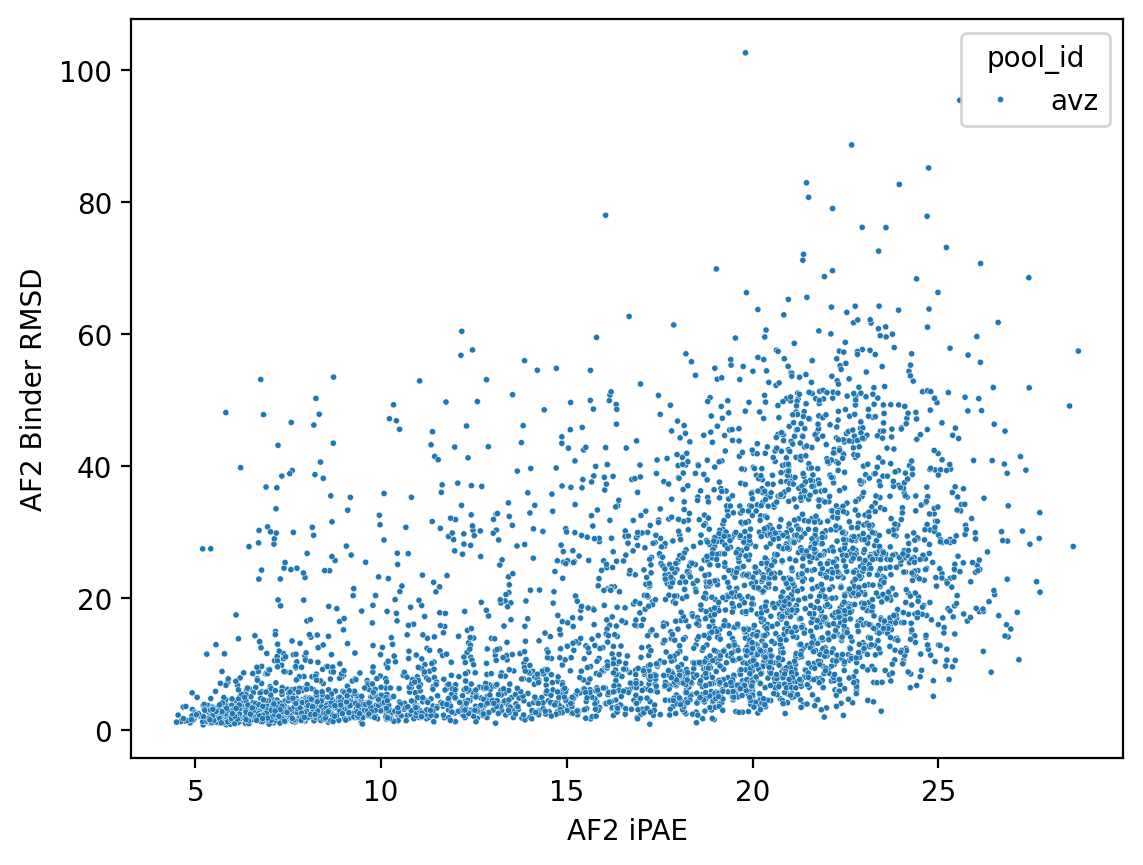

In [56]:
sns.scatterplot(designs, y='AF2 Target-aligned Binder RMSD', x='AF2 iPAE', hue='pool_id', s=5);

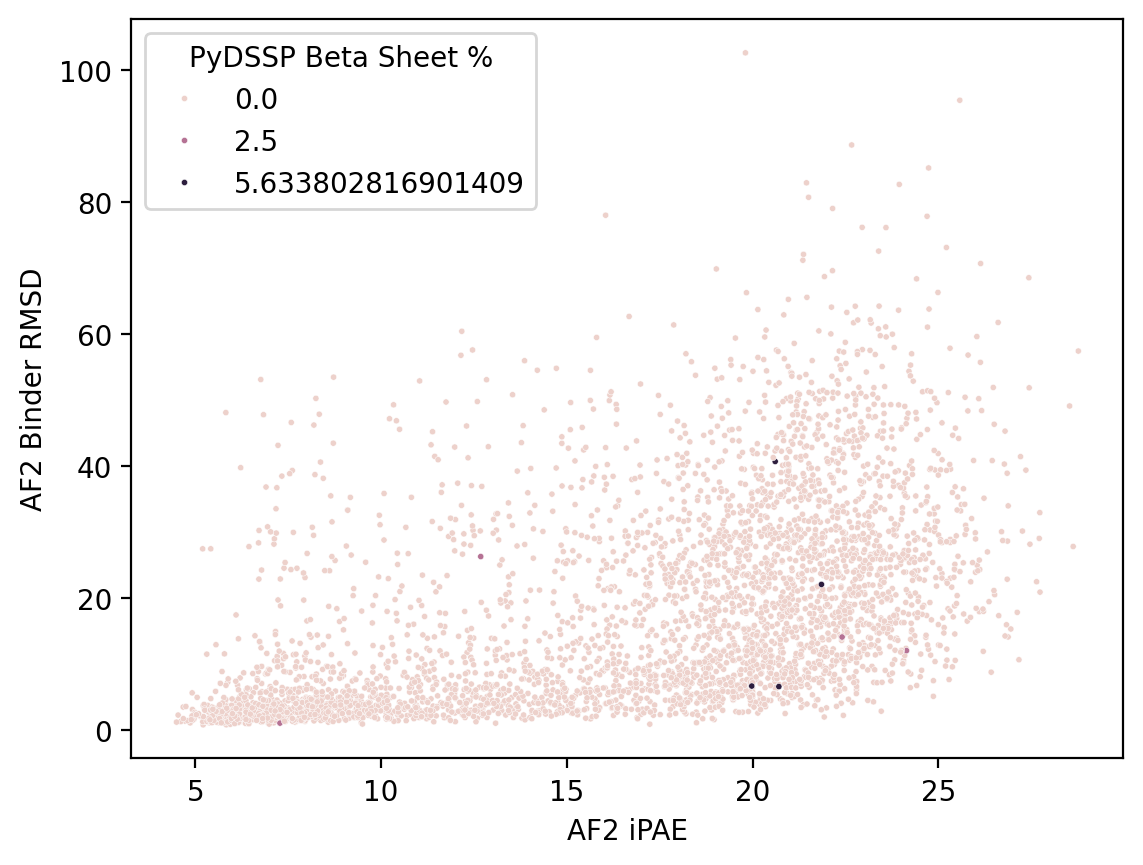

In [57]:
sns.scatterplot(designs, y='AF2 Target-aligned Binder RMSD', x='AF2 iPAE', hue=descriptors_rfdiffusion.PYDSSP_SHEET_PERCENT.name, s=5);

In [58]:
def plot_matrix(designs, thresholds):
    enabled_thresholds = [(k, t) for k, t in thresholds.items() if t.enabled]
    column_keys = [k for k, t in enabled_thresholds]
    column_descriptors = [descriptors.ALL_DESCRIPTORS_BY_KEY[k] for k in column_keys]
    column_names = [d.name for d in column_descriptors]
    g = sns.pairplot(designs[column_names + ['pool_id']], hue='pool_id', plot_kws=dict(s=5), diag_kind='hist');
    for i, (yd, (_, yt)) in enumerate(zip(column_descriptors, enabled_thresholds)):
        for j, (xd, (_, xt)) in enumerate(zip(column_descriptors, enabled_thresholds)):
            xbounds = xt.get_bounds(xd, designs[xd.name])
            ybounds = yt.get_bounds(yd, designs[yd.name])
            ax = g.axes[i][j]
            if i == j:
                ax.axvspan(*xbounds, alpha=0.2, color='#00ff00')
                continue
            assert ax.get_xlabel() == xd.name, f"{ax.get_xlabel()} != {xd.name}"
            assert ax.get_ylabel() == yd.name, f"{ax.get_ylabel()} != {yd.name}"
            print(xd.name, yd.name, xbounds, ybounds)
            ax.add_patch(plt.Rectangle((xbounds[0], ybounds[0]), abs(xbounds[1]-xbounds[0]), abs(ybounds[1]-ybounds[0]), alpha=0.2, color='#00ff00'))

AF2 Binder RMSD AF2 iPAE (0, 1.0) (0, 10.0)
AF2 Binder pLDDT AF2 iPAE (80.0, 100) (0, 10.0)
PyRosetta ddG AF2 iPAE (np.float64(-9433.628768920898), -30.0) (0, 10.0)
AF2 iPAE AF2 Binder RMSD (0, 10.0) (0, 1.0)
AF2 Binder pLDDT AF2 Binder RMSD (80.0, 100) (0, 1.0)
PyRosetta ddG AF2 Binder RMSD (np.float64(-9433.628768920898), -30.0) (0, 1.0)
AF2 iPAE AF2 Binder pLDDT (0, 10.0) (80.0, 100)
AF2 Binder RMSD AF2 Binder pLDDT (0, 1.0) (80.0, 100)
PyRosetta ddG AF2 Binder pLDDT (np.float64(-9433.628768920898), -30.0) (80.0, 100)
AF2 iPAE PyRosetta ddG (0, 10.0) (np.float64(-9433.628768920898), -30.0)
AF2 Binder RMSD PyRosetta ddG (0, 1.0) (np.float64(-9433.628768920898), -30.0)
AF2 Binder pLDDT PyRosetta ddG (80.0, 100) (np.float64(-9433.628768920898), -30.0)


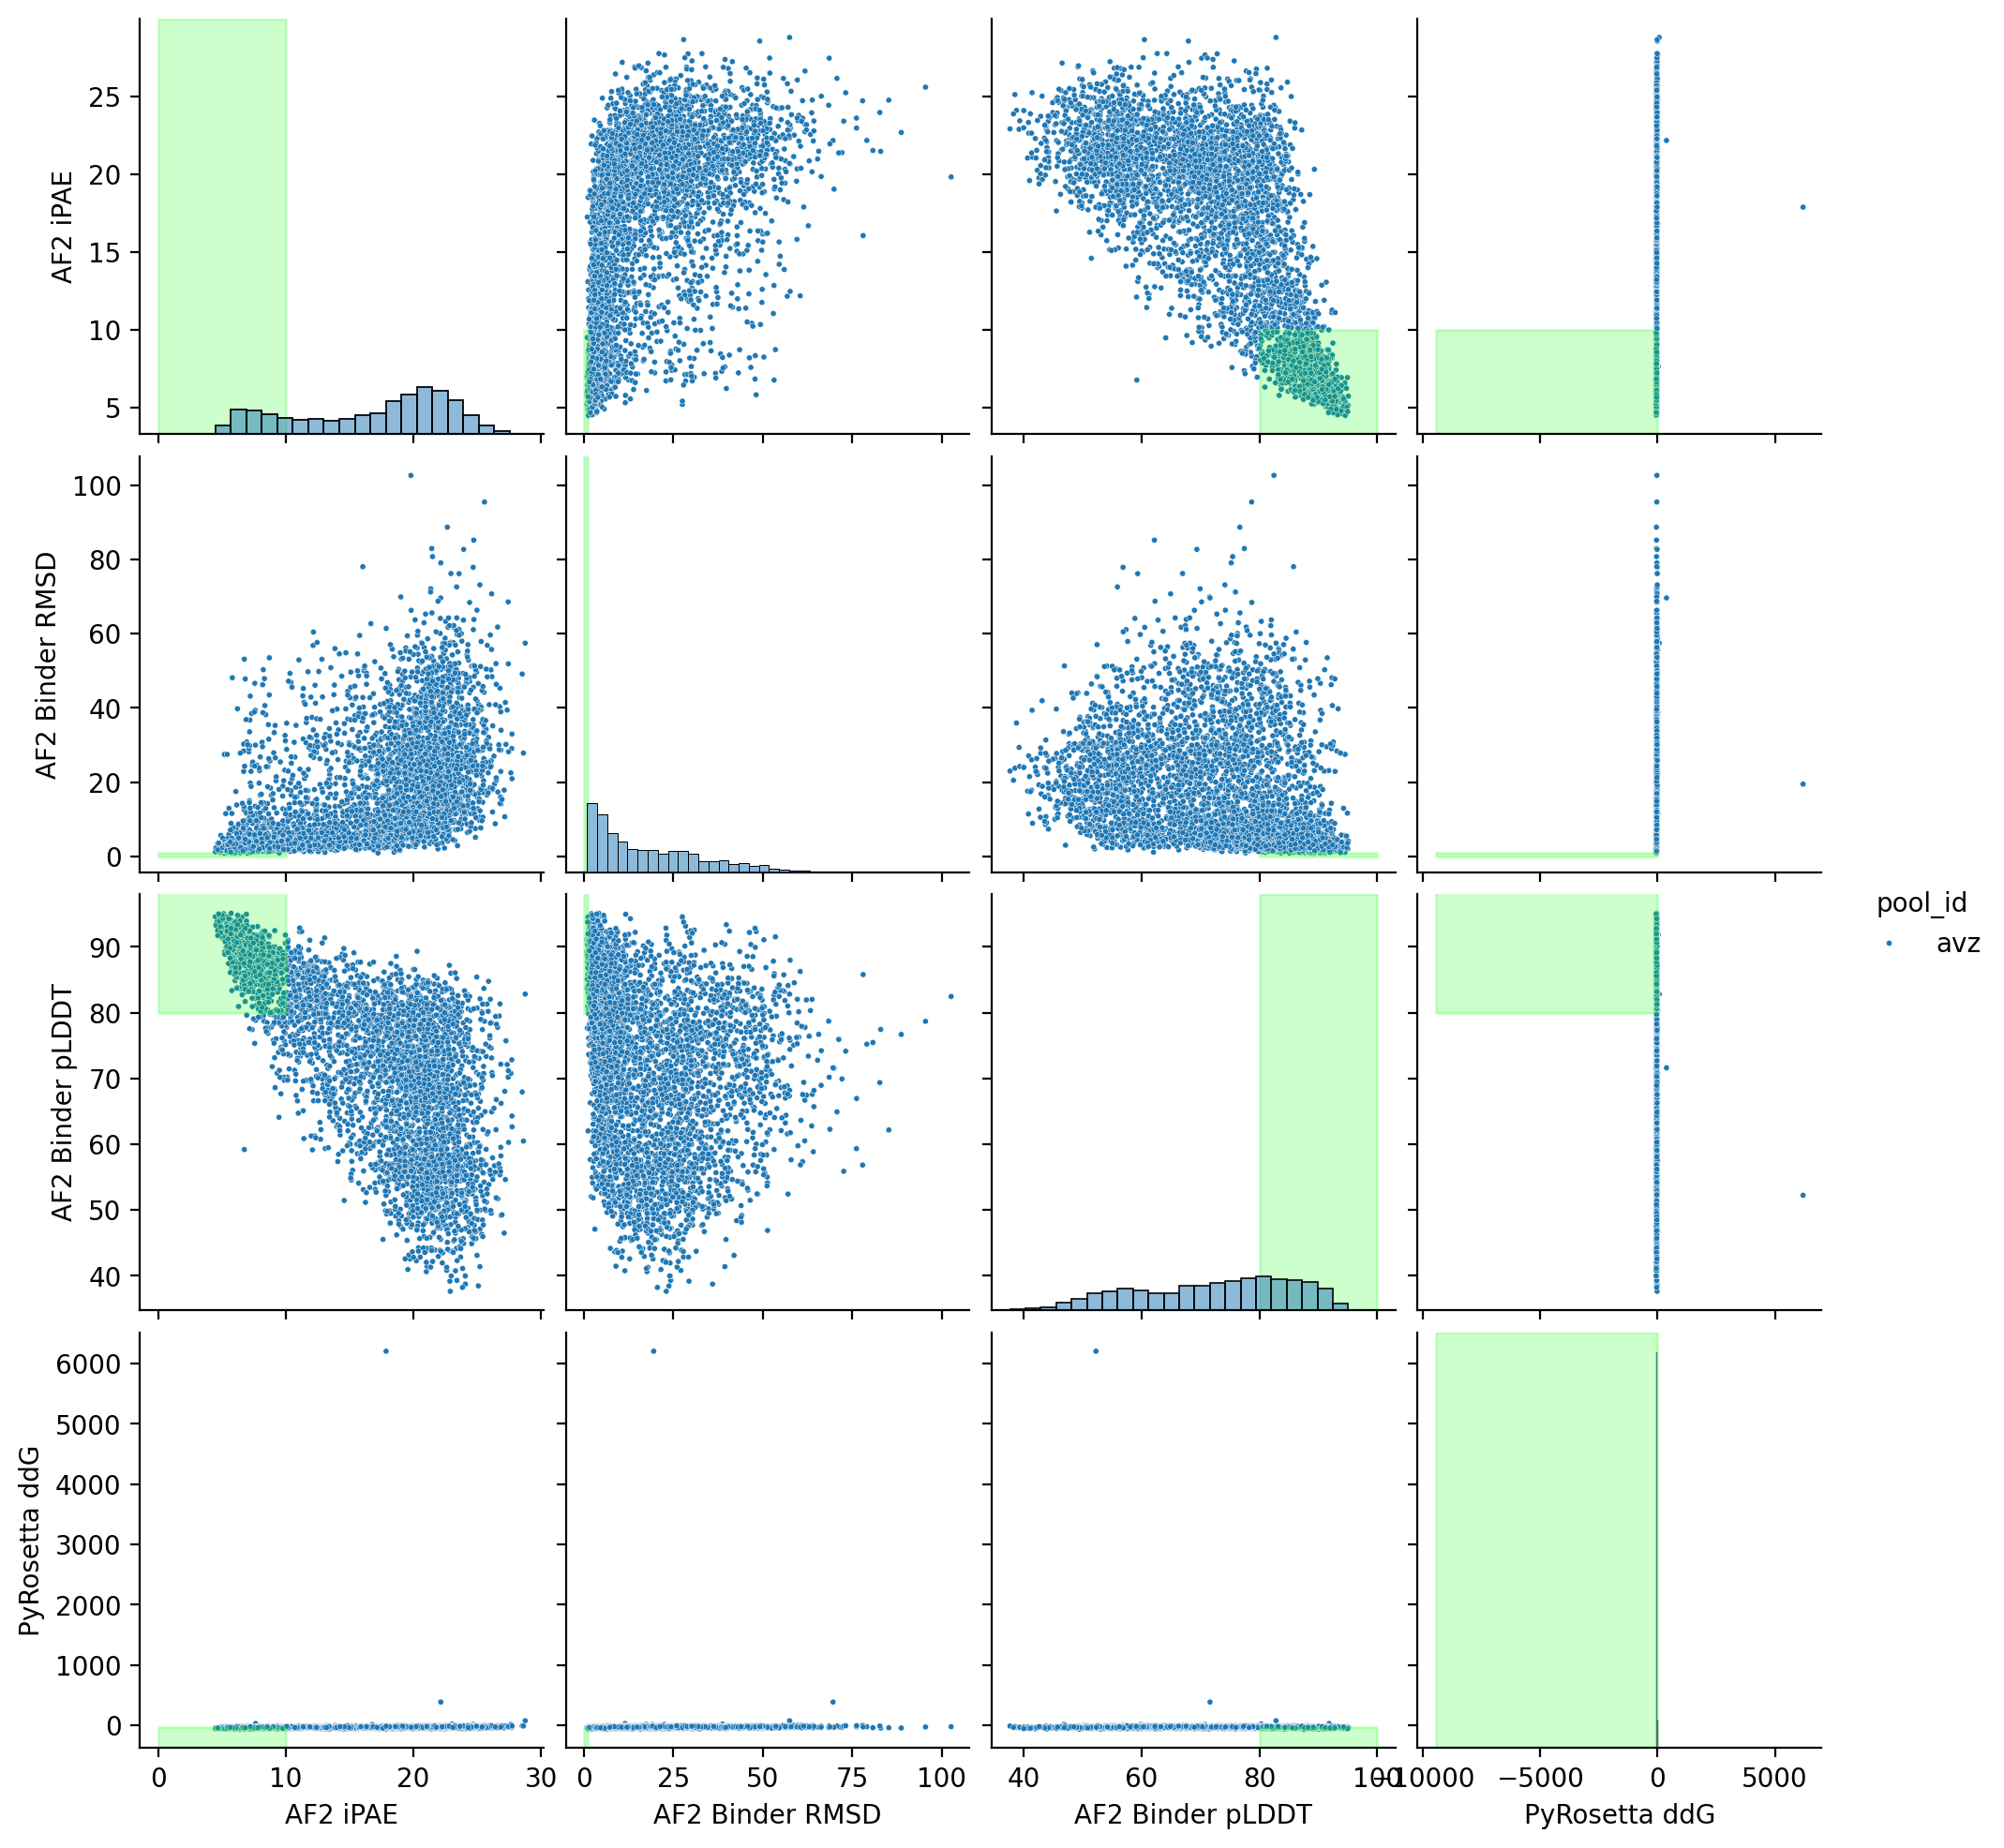

In [59]:
plot_matrix(designs, thresholds)

## Change acceptance thresholds

In [60]:
design_logic.update_acceptance_thresholds(pools=[pool], acceptance_thresholds=thresholds)

In [61]:
db.Design.count(accepted=True, pool_id=pool.id)

5